# Forecasting com modelos baseados em cohorts

Este notebook reescreve a ideia do artigo de Nicolai Vicol como um experimento reproduzível e didático. O objetivo não é fingir que um modelo simples é produção: é tornar visíveis as decisões, os trade-offs e os riscos de validação.

## O que vamos construir

1. Dados sintéticos de cadastros e conversões.
2. Uma tabela longa com as chaves registration_date, event_date e age.
3. Um modelo cohort-based mínimo: curva de conversão por idade + efeito do dia da semana + média móvel para o tamanho de cohorts futuras.
4. Um baseline temporal simples, baseado no último valor observado para cada dia da semana.
5. Avaliação walk-forward, sem embaralhar o tempo e sem usar tamanhos futuros durante o treino.
6. Testes automatizados executáveis no próprio notebook.

A implementação usa somente a biblioteca padrão do Python para rodar em um ambiente limpo. Em produção, as mesmas features podem alimentar GLM Poisson/Tweedie, GAM ou Gradient Boosting.


## Trade-offs antes do código

| Escolha | Vantagem | Custo ou risco |
|---|---|---|
| Série temporal agregada | Simples, barata e direta para prever o total | Perde atribuição por cohort e pode misturar aquisição, maturação e sazonalidade |
| Modelo por cohort | Explica quanto do futuro vem de cohorts antigas, recentes ou futuras | Exige mais dados, mais engenharia e uma tabela potencialmente grande |
| Curva por idade | Captura a queda inicial e a cauda longa de conversões | Uma curva global pode esconder mudanças de produto, canal ou país |
| GLM/GAM | Interpretabilidade e extrapolação de tendência; Poisson/Tweedie respeitam alvos positivos e assimétricos | Exige especificação de distribuição, link e transformações; pode ficar sensível à especificação |
| GBM | Captura não linearidades e interações com pouca engenharia manual | Árvores não extrapolam bem tendências fora do intervalo observado; aumenta o risco de overfitting |
| Cohorts futuras | Permitem decompor o forecast em aquisição futura e maturação | O forecast vira dois problemas: tamanho futuro das cohorts e conversão condicional por idade |
| Cutoff old/recent | Modelos diferentes podem tratar melhor cauda e início da curva | O cutoff é hiperparâmetro e precisa ser escolhido com validação, não por convenção |
| Validação aleatória | Mais rápida e familiar | Vaza informação futura; pode produzir uma estimativa otimista e inválida |

A regra prática deste notebook é: só vale pagar a complexidade do modelo por cohort se a decomposição for útil para decisão ou se a validação temporal mostrar ganho consistente sobre um baseline agregado.


## Referências consultadas

- Forecasting with cohort-based models — Nicolai Vicol:
  https://medium.com/towards-data-science/forecasting-with-cohort-based-models-e71003bc7ecd
- Forecasting: Principles and Practice — time series cross-validation:
  https://otexts.com/fpp3/tscv.html
- scikit-learn — TimeSeriesSplit:
  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
- statsmodels — Generalized Linear Models:
  https://www.statsmodels.org/stable/glm.html
- LightGBM — Parameters:
  https://lightgbm.readthedocs.io/en/stable/Parameters.html


In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from datetime import date, timedelta
from math import exp, sqrt, sin, pi
from random import Random
from statistics import mean
from typing import Dict, Iterable, List, Mapping, Sequence, Tuple
import unittest

print("Python pronto; nenhuma dependência externa é necessária.")


Python pronto; nenhuma dependência externa é necessária.


## 1. Dados sintéticos

Cada linha representa uma combinação de cohort e data de evento. O alvo é a quantidade de conversões naquela célula.

A simulação inclui três sinais:

- queda não linear da conversão conforme a idade aumenta;
- efeito do dia da semana;
- cohorts com tamanhos diferentes ao longo do tempo.

O modelo não recebe a fórmula geradora; ele vê apenas o histórico até a data de corte.


In [2]:
@dataclass(frozen=True)
class CohortCell:
    registration_date: date
    event_date: date
    age: int
    cohort_size: int
    conversions: int


def date_range(start: date, end: date) -> Iterable[date]:
    current = start
    while current <= end:
        yield current
        current += timedelta(days=1)


def poisson(rng: Random, lam: float) -> int:
    """Amostrador Poisson pequeno, suficiente para este exemplo didático."""
    if lam <= 0:
        return 0
    if lam > 30:
        return max(0, int(round(rng.gauss(lam, sqrt(lam)))))
    threshold = exp(-lam)
    product = 1.0
    count = 0
    while product > threshold:
        count += 1
        product *= rng.random()
    return count - 1


def latent_age_rate(age: int) -> float:
    """Taxa verdadeira usada somente para gerar os dados."""
    return 0.014 * exp(-age / 24.0) + 0.0012 * exp(-age / 240.0)


WEEKDAY_EFFECT = {
    0: 1.08, 1: 1.00, 2: 0.97, 3: 0.98, 4: 1.03, 5: 1.10, 6: 1.18
}

HOLIDAY_DAYS = {(1, 1), (7, 4), (12, 24), (12, 25), (12, 31)}
PROMOTION_DAYS = {(3, 15), (6, 1), (9, 1), (11, 25), (12, 23)}


def calendar_effect(day: date) -> float:
    """Sazonalidade anual, feriados e eventos comerciais conhecidos."""
    day_of_year = day.timetuple().tm_yday
    annual = 1.0 + 0.12 * sin(2.0 * pi * (day_of_year - 30) / 365.25)
    holiday = 0.72 if (day.month, day.day) in HOLIDAY_DAYS else 1.0
    promotion = 1.35 if (day.month, day.day) in PROMOTION_DAYS else 1.0
    black_friday = (
        day.month == 11
        and day.weekday() == 4
        and 23 <= day.day <= 29
    )
    return annual * holiday * promotion * (1.45 if black_friday else 1.0)


def generate_synthetic_data(
    start: date = date(2024, 1, 1),
    history_days: int = 300,
    forecast_days: int = 90,
    max_age: int = 420,
    seed: int = 7,
) -> Tuple[List[CohortCell], Dict[date, int], date, date, date]:
    """Gera histórico e futuro observável para podermos testar o forecast."""
    rng = Random(seed)
    origin = start + timedelta(days=history_days - 1)
    end = origin + timedelta(days=forecast_days)
    cohort_sizes: Dict[date, int] = {}
    cells: List[CohortCell] = []

    for index, registration_date in enumerate(date_range(start, end)):
        # Aquisição varia: o tamanho futuro será desconhecido pelo modelo.
        size = int(round(680 + 0.25 * index + 75 * sin(index / 18.0)))
        size = max(100, size)
        cohort_sizes[registration_date] = size
        quality = 1.0 + 0.05 * sin(index / 31.0)
        last_age = min(max_age, (end - registration_date).days)

        for age in range(last_age + 1):
            event_date = registration_date + timedelta(days=age)
            expected = (
                size
                * latent_age_rate(age)
                * WEEKDAY_EFFECT[event_date.weekday()]
                * calendar_effect(event_date)
                * quality
            )
            cells.append(
                CohortCell(
                    registration_date=registration_date,
                    event_date=event_date,
                    age=age,
                    cohort_size=size,
                    conversions=poisson(rng, expected),
                )
            )

    return cells, cohort_sizes, start, origin, end


cells, cohort_sizes, start_date, forecast_origin, end_date = generate_synthetic_data()
print(f"células: {len(cells):,}")
print(f"cohort inicial: {start_date} | origem: {forecast_origin} | fim observável: {end_date}")
print("exemplo:", cells[0])


células: 76,245
cohort inicial: 2024-01-01 | origem: 2024-10-26 | fim observável: 2025-01-24
exemplo: CohortCell(registration_date=datetime.date(2024, 1, 1), event_date=datetime.date(2024, 1, 1), age=0, cohort_size=680, conversions=5)


## 2. O modelo mínimo

Para uma célula (cohort, evento), estimamos:

previsão = tamanho_da_cohort × taxa_por_idade × fator_do_dia_da_semana

A taxa por idade é estimada de forma agregada:

taxa(age) = conversões_observadas(age) / exposição_observada(age)

Com suavização pelo valor global, isso se comporta como um baseline de Poisson com offset de exposição. Ele é deliberadamente simples: serve para explicar a mecânica e fornecer um ponto de comparação antes de usar um GLM ou GBM.


In [3]:
@dataclass
class CohortRateModel:
    age_rates: Dict[int, float]
    weekday_factors: Dict[int, float]
    size_forecast: float
    first_registration_date: date
    max_observed_age: int
    cutoff_age: int = 60
    calendar_aware: bool = True

    @classmethod
    def fit(
        cls,
        cells: Sequence[CohortCell],
        origin: date,
        cutoff_age: int = 60,
        smoothing_exposure: float = 40.0,
        size_window: int = 28,
        use_calendar_features: bool = True,
    ) -> "CohortRateModel":
        observed = [
            row for row in cells
            if row.registration_date <= origin and row.event_date <= origin
        ]
        if not observed:
            raise ValueError("não há células observadas antes da origem")

        conversions_by_age: Dict[int, float] = defaultdict(float)
        exposure_by_age: Dict[int, float] = defaultdict(float)
        sizes_by_registration: Dict[date, int] = {}

        for row in observed:
            calendar = calendar_effect(row.event_date) if use_calendar_features else 1.0
            conversions_by_age[row.age] += row.conversions / calendar
            exposure_by_age[row.age] += row.cohort_size
            sizes_by_registration[row.registration_date] = row.cohort_size

        total_conversions = sum(conversions_by_age.values())
        total_exposure = sum(exposure_by_age.values())
        global_rate = total_conversions / max(total_exposure, 1.0)
        max_observed_age = max(exposure_by_age)

        age_rates = {
            age: (
                conversions_by_age[age] + smoothing_exposure * global_rate
            ) / (exposure_by_age[age] + smoothing_exposure)
            for age in exposure_by_age
        }

        # Corrige o efeito de calendário depois da curva de idade.
        actual_by_weekday: Dict[int, float] = defaultdict(float)
        expected_by_weekday: Dict[int, float] = defaultdict(float)
        for row in observed:
            calendar = calendar_effect(row.event_date) if use_calendar_features else 1.0
            expected = row.cohort_size * age_rates[row.age] * calendar
            actual_by_weekday[row.event_date.weekday()] += row.conversions
            expected_by_weekday[row.event_date.weekday()] += expected

        weekday_factors = {}
        for weekday in range(7):
            denominator = expected_by_weekday[weekday]
            factor = (
                actual_by_weekday[weekday] / denominator
                if denominator else 1.0
            )
            weekday_factors[weekday] = min(1.35, max(0.70, factor))

        recent_sizes = [
            size
            for registration, size in sorted(sizes_by_registration.items())[-size_window:]
        ]

        return cls(
            age_rates=age_rates,
            weekday_factors=weekday_factors,
            size_forecast=mean(recent_sizes),
            first_registration_date=min(sizes_by_registration),
            max_observed_age=max_observed_age,
            cutoff_age=cutoff_age,
            calendar_aware=use_calendar_features,
        )

    def rate(self, age: int) -> float:
        if age in self.age_rates:
            return self.age_rates[age]
        # Extrapolação conservadora da cauda além do maior age observado.
        last_rate = self.age_rates[self.max_observed_age]
        extra_age = max(0, age - self.max_observed_age)
        return last_rate * exp(-0.004 * extra_age)

    def forecast_cells(
        self,
        origin: date,
        horizon: int,
        known_cohort_sizes: Mapping[date, int],
    ) -> List[dict]:
        """Prevê células e nunca consulta o tamanho real de cohorts futuras."""
        predictions: List[dict] = []

        for step in range(1, horizon + 1):
            event_date = origin + timedelta(days=step)
            for registration_date in date_range(
                self.first_registration_date, event_date
            ):
                if registration_date <= origin:
                    if registration_date not in known_cohort_sizes:
                        continue
                    size = known_cohort_sizes[registration_date]
                    age_at_origin = (origin - registration_date).days
                    segment = (
                        "old" if age_at_origin >= self.cutoff_age else "recent"
                    )
                else:
                    size = self.size_forecast
                    segment = "future"

                age = (event_date - registration_date).days
                prediction = (
                    size
                    * self.rate(age)
                    * self.weekday_factors[event_date.weekday()]
                    * (calendar_effect(event_date) if self.calendar_aware else 1.0)
                )
                predictions.append({
                    "registration_date": registration_date,
                    "event_date": event_date,
                    "age": age,
                    "segment": segment,
                    "prediction": max(0.0, prediction),
                })

        return predictions


def aggregate_predictions(predictions: Iterable[dict]) -> Dict[date, float]:
    totals: Dict[date, float] = defaultdict(float)
    for row in predictions:
        totals[row["event_date"]] += row["prediction"]
    return dict(totals)


def aggregate_by_segment(predictions: Iterable[dict]) -> Dict[str, float]:
    totals: Dict[str, float] = defaultdict(float)
    for row in predictions:
        totals[row["segment"]] += row["prediction"]
    return dict(totals)


In [4]:
known_sizes = {
    registration: size
    for registration, size in cohort_sizes.items()
    if registration <= forecast_origin
}
model = CohortRateModel.fit(cells, forecast_origin, cutoff_age=60)
predicted_cells = model.forecast_cells(
    origin=forecast_origin,
    horizon=30,
    known_cohort_sizes=known_sizes,
)
predicted_totals = aggregate_predictions(predicted_cells)
segment_totals = aggregate_by_segment(predicted_cells)

print("taxas estimadas por idade:")
for age in [0, 1, 7, 14, 30, 60, 120, 240]:
    print(f"  age={age:>3}: {model.rate(age):.5f}")
print(
    "fatores por dia da semana:",
    {key: round(value, 3) for key, value in model.weekday_factors.items()},
)
print(
    "contribuição prevista por segmento:",
    {key: round(value, 1) for key, value in segment_totals.items()},
)
print(
    "primeiros 3 dias:",
    {str(key): round(value, 1) for key, value in list(predicted_totals.items())[:3]},
)


taxas estimadas por idade:
  age=  0: 0.01619
  age=  1: 0.01564
  age=  7: 0.01195
  age= 14: 0.00945
  age= 30: 0.00545
  age= 60: 0.00210
  age=120: 0.00074
  age=240: 0.00045
fatores por dia da semana: {0: 1.039, 1: 0.953, 2: 0.919, 3: 0.933, 4: 0.987, 5: 1.049, 6: 1.113}
contribuição prevista por segmento: {'old': 3011.2, 'recent': 5042.7, 'future': 3599.5}
primeiros 3 dias: {'2024-10-27': 422.7, '2024-10-28': 394.7, '2024-10-29': 362.0}


## 3. Baseline agregado e métricas

O baseline usa apenas a série diária total. Para cada dia futuro, repete o último valor histórico observado no mesmo dia da semana.

Esse baseline é importante porque uma arquitetura mais complexa não deve ser aceita só por parecer mais sofisticada. O resultado relevante é o erro fora da amostra, no horizonte que realmente importa para o negócio.


In [5]:
def daily_actuals(cells: Iterable[CohortCell]) -> Dict[date, float]:
    totals: Dict[date, float] = defaultdict(float)
    for row in cells:
        totals[row.event_date] += row.conversions
    return dict(totals)


def seasonal_naive_forecast(
    actuals: Mapping[date, float],
    origin: date,
    horizon: int,
) -> Dict[date, float]:
    observed = {day: value for day, value in actuals.items() if day <= origin}
    fallback = mean(list(observed.values())[-28:])
    result: Dict[date, float] = {}

    for step in range(1, horizon + 1):
        day = origin + timedelta(days=step)
        candidates = [
            (candidate, value)
            for candidate, value in observed.items()
            if candidate.weekday() == day.weekday()
        ]
        result[day] = candidates[-1][1] if candidates else fallback

    return result


def mean_absolute_error(
    actual: Sequence[float],
    predicted: Sequence[float],
) -> float:
    return mean(abs(a - p) for a, p in zip(actual, predicted))


def wape(actual: Sequence[float], predicted: Sequence[float]) -> float:
    denominator = sum(abs(value) for value in actual)
    return sum(abs(a - p) for a, p in zip(actual, predicted)) / max(denominator, 1.0)


def smape(actual: Sequence[float], predicted: Sequence[float]) -> float:
    terms = []
    for a, p in zip(actual, predicted):
        denominator = abs(a) + abs(p)
        if denominator:
            terms.append(2.0 * abs(a - p) / denominator)
    return mean(terms) if terms else 0.0


actuals = daily_actuals(cells)
actual_window = [
    actuals[day]
    for day in sorted(actuals)
    if forecast_origin < day <= forecast_origin + timedelta(days=30)
]
cohort_window = [predicted_totals[day] for day in sorted(predicted_totals)]
naive_totals = seasonal_naive_forecast(actuals, forecast_origin, 30)
naive_window = [naive_totals[day] for day in sorted(naive_totals)]

print("30 dias à frente")
print(
    f"cohort model | MAE={mean_absolute_error(actual_window, cohort_window):.2f}"
    f" | WAPE={wape(actual_window, cohort_window):.2%}"
    f" | sMAPE={smape(actual_window, cohort_window):.2%}"
)
print(
    f"baseline     | MAE={mean_absolute_error(actual_window, naive_window):.2f}"
    f" | WAPE={wape(actual_window, naive_window):.2%}"
    f" | sMAPE={smape(actual_window, naive_window):.2%}"
)


30 dias à frente
cohort model | MAE=15.30 | WAPE=4.02% | sMAPE=4.07%
baseline     | MAE=23.70 | WAPE=6.22% | sMAPE=6.11%


## 4. Walk-forward validation

Cada origem refaz o treino usando somente células com event_date <= origin. O horizonte é avaliado depois da origem. Isso imita o uso real: no dia da previsão, o futuro ainda não existe.

Além do erro médio, olhamos a estabilidade por origem. Um modelo que ganha em uma única janela e perde nas demais pode estar apenas se beneficiando de uma fase específica do negócio.


In [6]:
def walk_forward_evaluation(
    cells: Sequence[CohortCell],
    cohort_sizes: Mapping[date, int],
    origins: Sequence[date],
    horizon: int,
    cutoff_age: int = 60,
) -> List[dict]:
    actuals = daily_actuals(cells)
    results: List[dict] = []

    for origin in origins:
        known_sizes = {
            day: size
            for day, size in cohort_sizes.items()
            if day <= origin
        }
        model = CohortRateModel.fit(cells, origin, cutoff_age=cutoff_age)
        cohort_prediction = aggregate_predictions(
            model.forecast_cells(origin, horizon, known_sizes)
        )
        naive_prediction = seasonal_naive_forecast(actuals, origin, horizon)

        days = [
            origin + timedelta(days=step)
            for step in range(1, horizon + 1)
        ]
        y_true = [actuals[day] for day in days]
        y_cohort = [cohort_prediction[day] for day in days]
        y_naive = [naive_prediction[day] for day in days]

        results.append({
            "origin": origin,
            "cohort_wape": wape(y_true, y_cohort),
            "naive_wape": wape(y_true, y_naive),
            "cohort_mae": mean_absolute_error(y_true, y_cohort),
            "naive_mae": mean_absolute_error(y_true, y_naive),
        })

    return results


origins = [
    start_date + timedelta(days=day)
    for day in [180, 210, 240, 270, 299]
]
evaluation = walk_forward_evaluation(
    cells,
    cohort_sizes,
    origins,
    horizon=30,
)

for row in evaluation:
    print(
        f"origem={row['origin']} | "
        f"cohort WAPE={row['cohort_wape']:.2%} | "
        f"naive WAPE={row['naive_wape']:.2%}"
    )

print(
    "WAPE médio cohort:",
    f"{mean(row['cohort_wape'] for row in evaluation):.2%}",
)
print(
    "WAPE médio naive :",
    f"{mean(row['naive_wape'] for row in evaluation):.2%}",
)


origem=2024-06-29 | cohort WAPE=5.56% | naive WAPE=8.20%
origem=2024-07-29 | cohort WAPE=4.02% | naive WAPE=6.21%
origem=2024-08-28 | cohort WAPE=4.49% | naive WAPE=6.47%
origem=2024-09-27 | cohort WAPE=3.79% | naive WAPE=6.09%
origem=2024-10-26 | cohort WAPE=4.02% | naive WAPE=6.22%
WAPE médio cohort: 4.38%
WAPE médio naive : 6.64%


## 5. Testes automatizados

Estes testes cobrem invariantes que costumam quebrar modelos de cohort:

- reprodutibilidade dos dados sintéticos;
- horizonte e não-negatividade das previsões;
- ausência de vazamento pelo tamanho real de cohorts futuras;
- métricas básicas;
- execução da validação walk-forward.

Em um projeto real, estes testes deveriam ficar em arquivos separados e rodar no CI.


In [7]:
class CohortForecastTests(unittest.TestCase):
    @classmethod
    def setUpClass(cls):
        (
            cls.cells,
            cls.sizes,
            cls.start,
            cls.origin,
            cls.end,
        ) = generate_synthetic_data()

    def test_data_is_reproducible(self):
        other = generate_synthetic_data()
        self.assertEqual(self.cells[:20], other[0][:20])
        self.assertEqual(self.sizes, other[1])

    def test_forecast_has_correct_horizon_and_nonnegative_values(self):
        known = {
            day: size
            for day, size in self.sizes.items()
            if day <= self.origin
        }
        model = CohortRateModel.fit(self.cells, self.origin)
        predictions = aggregate_predictions(
            model.forecast_cells(self.origin, 14, known)
        )
        expected_days = {
            self.origin + timedelta(days=i)
            for i in range(1, 15)
        }
        self.assertEqual(set(predictions), expected_days)
        self.assertTrue(all(value >= 0 for value in predictions.values()))

    def test_future_sizes_do_not_leak_into_forecast(self):
        known = {
            day: size
            for day, size in self.sizes.items()
            if day <= self.origin
        }
        model = CohortRateModel.fit(self.cells, self.origin)
        forecast_with_known = model.forecast_cells(self.origin, 14, known)
        forecast_with_all_sizes = model.forecast_cells(
            self.origin,
            14,
            self.sizes,
        )
        self.assertEqual(forecast_with_known, forecast_with_all_sizes)

    def test_metrics_are_zero_for_perfect_prediction(self):
        values = [0.0, 2.0, 5.0]
        self.assertEqual(mean_absolute_error(values, values), 0.0)
        self.assertEqual(wape(values, values), 0.0)
        self.assertEqual(smape(values, values), 0.0)

    def test_walk_forward_runs_for_multiple_origins(self):
        origins = [
            self.start + timedelta(days=day)
            for day in [180, 210, 240]
        ]
        result = walk_forward_evaluation(
            self.cells,
            self.sizes,
            origins,
            horizon=14,
        )
        self.assertEqual(len(result), 3)
        self.assertTrue(
            all(0 <= row["cohort_wape"] for row in result)
        )


suite = unittest.defaultTestLoader.loadTestsFromTestCase(CohortForecastTests)
test_result = unittest.TextTestRunner(verbosity=2).run(suite)


test_data_is_reproducible (__main__.CohortForecastTests.test_data_is_reproducible) ... ok
test_forecast_has_correct_horizon_and_nonnegative_values (__main__.CohortForecastTests.test_forecast_has_correct_horizon_and_nonnegative_values) ... ok
test_future_sizes_do_not_leak_into_forecast (__main__.CohortForecastTests.test_future_sizes_do_not_leak_into_forecast) ... ok
test_metrics_are_zero_for_perfect_prediction (__main__.CohortForecastTests.test_metrics_are_zero_for_perfect_prediction) ... ok
test_walk_forward_runs_for_multiple_origins (__main__.CohortForecastTests.test_walk_forward_runs_for_multiple_origins) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.675s

OK


## 6. Como evoluir para produção

O baseline deste notebook deixa algumas decisões explícitas, mas não resolve todos os problemas de um produto real.

### Features

Separe features pela chave em que elas são conhecidas:

- por cohort: tamanho, canal, país, plano de entrada;
- por data de evento: dia da semana, feriado, campanha, preço;
- por (cohort, evento): idade, janela desde a última interação, maturidade.

### Modelo

Para contagens, comece comparando Poisson e Negative Binomial. Para alvos positivos com muitos zeros e maior variância, avalie Tweedie. Um GLM tende a ser mais transparente e extrapolar tendência com mais segurança; um GBM tende a capturar melhor interações, mas não deve ser usado para extrapolar uma tendência que nunca apareceu no treino.

Com statsmodels, a forma conceitual é:

    import statsmodels.api as sm

    X = sm.add_constant(features)
    model = sm.GLM(
        y,
        X,
        family=sm.families.Poisson(),
        exposure=cohort_size,
    ).fit()

Com LightGBM, as opções poisson e tweedie existem como objetivos, mas a validação precisa continuar respeitando o tempo.

### Validação e operação

- use várias origens e o mesmo horizonte do processo decisório;
- mantenha um baseline agregado;
- simule atrasos de dados e campanhas conhecidas apenas ex-ante;
- monitore erro por idade, cohort, canal e segmento;
- reconcilie o total previsto com o total observado;
- produza intervalos de previsão, não somente um número pontual;
- trate o forecast de cohorts futuras como um segundo modelo, com sua própria incerteza.

### Regra de decisão

Use o modelo por cohort quando a atribuição e o diagnóstico forem parte do valor do forecast. Use o agregado quando o problema for somente prever o total, os dados de cohort forem frágeis ou o ganho fora da amostra não compensar a complexidade.


## 7. Explorando os gráficos

Os gráficos abaixo respondem perguntas diferentes:

1. As cohorts têm curvas de maturação parecidas?
2. Onde está a cauda longa e em que idade ela deixa de ser relevante?
3. O total previsto vem de cohorts antigas, recentes ou futuras?
4. O ganho contra o baseline é consistente em várias origens?

As figuras são SVGs gerados no próprio notebook, sem pandas, numpy ou matplotlib.


In [8]:
from html import escape
from IPython.display import SVG, display


def render_line_chart(
    series: Sequence[Tuple[str, Sequence[float]]],
    x_labels: Sequence[str],
    title: str,
    y_label: str,
    width: int = 920,
    height: int = 380,
) -> SVG:
    colors = ["#2563eb", "#dc2626", "#059669", "#d97706", "#7c3aed", "#0891b2"]
    left, right, top, bottom = 72, 24, 48, 62
    plot_width = width - left - right
    plot_height = height - top - bottom
    values = [value for _, values in series for value in values]
    y_min = min(0.0, min(values))
    y_max = max(values) * 1.10 if values else 1.0
    y_max = max(y_max, 1.0e-9)

    def x_position(index: int) -> float:
        denominator = max(len(x_labels) - 1, 1)
        return left + plot_width * index / denominator

    def y_position(value: float) -> float:
        return top + plot_height * (y_max - value) / max(y_max - y_min, 1.0e-9)

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" '
        f'width="100%" viewBox="0 0 {width} {height}" '
        f'role="img" aria-label="{escape(title)}">',
        f"<title>{escape(title)}</title>",
        f'<text x="{left}" y="24" font-size="16" font-weight="600">{escape(title)}</text>',
        f'<text x="{left}" y="{height - 10}" font-size="12">{escape("idade / data")}</text>',
        f'<text x="16" y="{top + plot_height / 2}" font-size="12" '
        f'transform="rotate(-90 16 {top + plot_height / 2})">{escape(y_label)}</text>',
    ]

    for tick in range(6):
        value = y_min + (y_max - y_min) * tick / 5
        y = y_position(value)
        parts.append(
            f'<line x1="{left}" y1="{y:.1f}" x2="{width - right}" y2="{y:.1f}" '
            f'stroke="#d1d5db" stroke-width="1"/>'
        )
        parts.append(
            f'<text x="{left - 8}" y="{y + 4:.1f}" text-anchor="end" '
            f'font-size="11">{value:.2f}</text>'
        )

    tick_indexes = sorted(set([0, len(x_labels) - 1] + list(range(0, len(x_labels), max(1, len(x_labels) // 6)))))
    for index in tick_indexes:
        x = x_position(index)
        parts.append(
            f'<line x1="{x:.1f}" y1="{top}" x2="{x:.1f}" y2="{top + plot_height}" '
            f'stroke="#f3f4f6" stroke-width="1"/>'
        )
        parts.append(
            f'<text x="{x:.1f}" y="{top + plot_height + 20}" text-anchor="middle" '
            f'font-size="11">{escape(str(x_labels[index]))}</text>'
        )

    for series_index, (name, values_for_series) in enumerate(series):
        points = " ".join(
            f"{x_position(index):.1f},{y_position(value):.1f}"
            for index, value in enumerate(values_for_series)
        )
        color = colors[series_index % len(colors)]
        parts.append(
            f'<polyline points="{points}" fill="none" stroke="{color}" '
            f'stroke-width="2.5" stroke-linejoin="round" stroke-linecap="round"/>'
        )
        parts.append(
            f'<line x1="{left + series_index * 150}" y1="{height - 34}" '
            f'x2="{left + 18 + series_index * 150}" y2="{height - 34}" '
            f'stroke="{color}" stroke-width="3"/>'
        )
        parts.append(
            f'<text x="{left + 24 + series_index * 150}" y="{height - 30}" '
            f'font-size="11">{escape(name)}</text>'
        )

    parts.append(
        f'<rect x="{left}" y="{top}" width="{plot_width}" height="{plot_height}" '
        f'fill="none" stroke="#9ca3af" stroke-width="1"/>'
    )
    parts.append("</svg>")
    return SVG("".join(parts))


def render_heatmap(
    rows: Sequence[Tuple[str, Sequence[float]]],
    column_labels: Sequence[str],
    title: str,
    width: int = 920,
) -> SVG:
    left, top, cell_width, cell_height = 105, 58, 12, 28
    height = top + len(rows) * cell_height + 58
    values = [value for _, row in rows for value in row]
    minimum, maximum = min(values), max(values)

    def color(value: float) -> str:
        ratio = (value - minimum) / max(maximum - minimum, 1.0e-9)
        red = int(239 - 190 * ratio)
        green = int(246 - 180 * ratio)
        blue = int(255 - 45 * ratio)
        return f"rgb({red},{green},{blue})"

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="100%" '
        f'viewBox="0 0 {width} {height}" role="img" aria-label="{escape(title)}">',
        f"<title>{escape(title)}</title>",
        f'<text x="{left}" y="24" font-size="16" font-weight="600">{escape(title)}</text>',
        f'<text x="{left}" y="44" font-size="11">idade</text>',
    ]

    for row_index, (row_label, values_for_row) in enumerate(rows):
        y = top + row_index * cell_height
        parts.append(
            f'<text x="{left - 8}" y="{y + 19}" text-anchor="end" font-size="11">'
            f'{escape(row_label)}</text>'
        )
        for column_index, value in enumerate(values_for_row):
            x = left + column_index * cell_width
            parts.append(
                f'<rect x="{x}" y="{y}" width="{cell_width}" height="{cell_height}" '
                f'fill="{color(value)}" stroke="#ffffff" stroke-width="0.5">'
                f'<title>{escape(row_label)}, age {column_index}: {value:.5f}</title></rect>'
            )

    for column_index in range(0, len(column_labels), max(1, len(column_labels) // 6)):
        x = left + column_index * cell_width + cell_width / 2
        parts.append(
            f'<text x="{x}" y="{top + len(rows) * cell_height + 18}" '
            f'text-anchor="middle" font-size="10">{escape(str(column_labels[column_index]))}</text>'
        )

    parts.extend([
        f'<text x="{left}" y="{height - 8}" font-size="11">'
        f'azul claro = menor taxa; azul escuro = maior taxa</text>',
        "</svg>",
    ])
    return SVG("".join(parts))


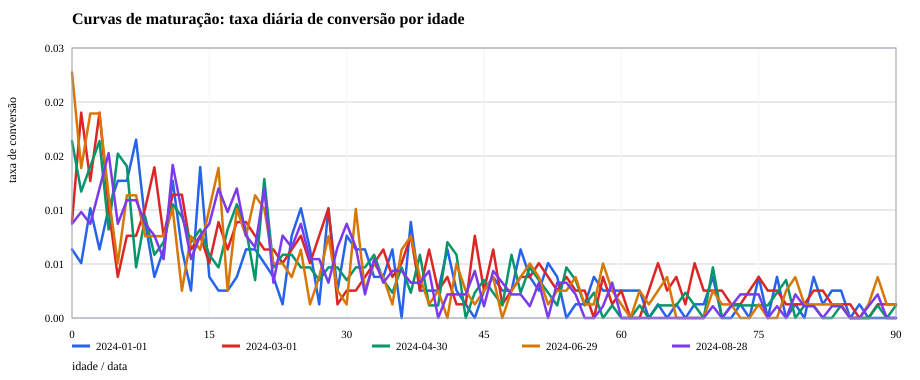

In [9]:
# Gráfico 1: curvas de maturação de cohorts selecionadas.
selected_registrations = [
    start_date + timedelta(days=day)
    for day in [0, 60, 120, 180, 240]
]
ages_to_plot = list(range(0, 91))
maturation_series = []

for registration_date in selected_registrations:
    selected = {
        row.age: row.conversions / row.cohort_size
        for row in cells
        if row.registration_date == registration_date and row.age <= 90
    }
    maturation_series.append(
        (
            str(registration_date),
            [selected.get(age, 0.0) for age in ages_to_plot],
        )
    )

display(
    render_line_chart(
        maturation_series,
        [str(age) for age in ages_to_plot],
        "Curvas de maturação: taxa diária de conversão por idade",
        "taxa de conversão",
    )
)


### Como ler

Se as curvas são aproximadamente paralelas quando alinhadas por idade, a hipótese de compartilhar uma curva de maturação é plausível. Diferenças sistemáticas entre cohorts podem indicar mudança de canal, produto, preço ou qualidade da aquisição.

A queda rápida no início e a persistência próxima de zero depois de muitas idades representam a cauda longa. O cutoff old/recent deve ficar próximo de uma região em que a idade deixa de explicar grande parte do sinal, mas isso precisa ser confirmado por validação.


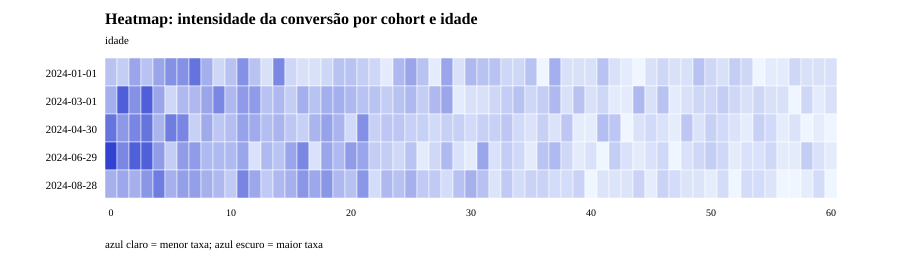

In [10]:
# Gráfico 2: heatmap de taxa por cohort e idade.
heatmap_rows = []

for registration_date in selected_registrations:
    selected = {
        row.age: row.conversions / row.cohort_size
        for row in cells
        if row.registration_date == registration_date and row.age <= 60
    }
    heatmap_rows.append(
        (
            str(registration_date),
            [selected.get(age, 0.0) for age in range(61)],
        )
    )

display(
    render_heatmap(
        heatmap_rows,
        [str(age) for age in range(61)],
        "Heatmap: intensidade da conversão por cohort e idade",
    )
)


### Como ler

As linhas mostram cohorts; as colunas mostram a idade. Uma faixa vertical forte no começo indica conversões precoces. Se uma linha inteira fica mais clara ou mais escura, isso aponta para um efeito específico da cohort, não apenas para a idade.

Esse gráfico também ajuda a encontrar dados quebrados: idades ausentes, cohorts com tamanho zero ou uma mudança abrupta de instrumentação aparecem como buracos ou faixas atípicas.


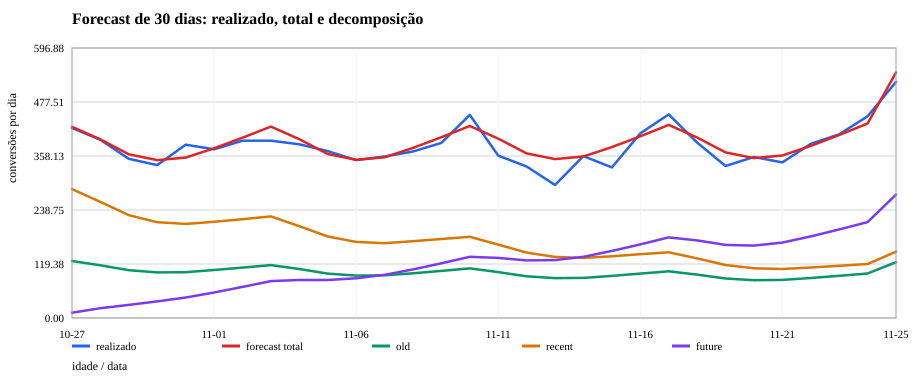

In [11]:
# Gráfico 3: realizado versus forecast e origem do forecast.
forecast_days = sorted(predicted_totals)
segment_by_day = defaultdict(lambda: defaultdict(float))

for row in predicted_cells:
    segment_by_day[row["event_date"]][row["segment"]] += row["prediction"]

comparison_series = [
    ("realizado", [actuals[day] for day in forecast_days]),
    ("forecast total", [predicted_totals[day] for day in forecast_days]),
    ("old", [segment_by_day[day]["old"] for day in forecast_days]),
    ("recent", [segment_by_day[day]["recent"] for day in forecast_days]),
    ("future", [segment_by_day[day]["future"] for day in forecast_days]),
]

display(
    render_line_chart(
        comparison_series,
        [str(day)[5:] for day in forecast_days],
        "Forecast de 30 dias: realizado, total e decomposição",
        "conversões por dia",
    )
)


### Como ler

A linha do forecast total deve acompanhar o realizado sem perder o nível ou o padrão semanal. As linhas old, recent e future explicam de onde vem o número:

- old: cauda de cohorts já maduras;
- recent: cohorts existentes ainda em maturação;
- future: cohorts que ainda nem existiam na data da previsão.

A decomposição é uma vantagem operacional do modelo cohort-based: ela permite discutir se o risco está em aquisição futura ou na conversão das cohorts já adquiridas.


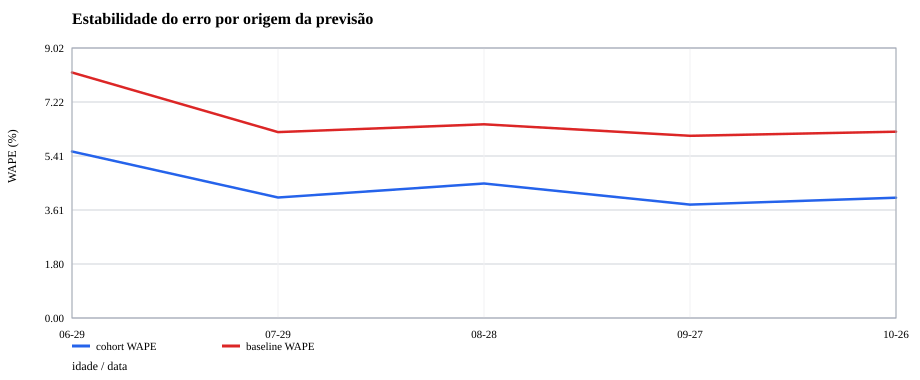

In [12]:
# Gráfico 4: estabilidade do erro nas origens walk-forward.
evaluation_series = [
    ("cohort WAPE", [row["cohort_wape"] * 100 for row in evaluation]),
    ("baseline WAPE", [row["naive_wape"] * 100 for row in evaluation]),
]

display(
    render_line_chart(
        evaluation_series,
        [str(row["origin"])[5:] for row in evaluation],
        "Estabilidade do erro por origem da previsão",
        "WAPE (%)",
    )
)


### Como ler

O resultado relevante não é somente a última origem. Se o cohort model ganha de forma consistente, há evidência melhor de que a estrutura está ajudando. Se o baseline ganha em algumas fases, investigue mudanças de regime, sazonalidade não modelada ou erro no forecast de tamanhos das cohorts futuras.

Neste exemplo os dados são sintéticos; os gráficos demonstram o raciocínio, não garantem desempenho em dados reais.


## 8. Réplica das 17 figuras do artigo

A seção anterior mostrou quatro gráficos analíticos. Nesta seção, cada figura do artigo é reproduzida com os dados sintéticos deste notebook.

A correspondência é conceitual: o artigo usa Plotly/Matplotlib e dados sintéticos próprios; aqui usamos SVG puro e as mesmas perguntas analíticas sobre um processo gerador equivalente: Poisson, decaimento por idade, tendência, sazonalidade, feriados e eventos comerciais. O repositório do autor explicita essa estrutura multiplicativa e o alvo Poisson.


In [13]:
def render_optional_line_chart(
    series: Sequence[Tuple[str, Sequence[float | None], bool]],
    x_labels: Sequence[str],
    title: str,
    y_label: str,
    width: int = 920,
    height: int = 380,
) -> SVG:
    colors = ["#2563eb", "#dc2626", "#059669", "#d97706", "#7c3aed", "#0891b2"]
    left, right, top, bottom = 72, 24, 48, 62
    plot_width = width - left - right
    plot_height = height - top - bottom
    values = [
        value
        for _, values_for_series, _ in series
        for value in values_for_series
        if value is not None
    ]
    y_min = min(0.0, min(values)) if values else 0.0
    y_max = max(values) * 1.10 if values else 1.0
    y_max = max(y_max, 1.0e-9)

    def x_position(index: int) -> float:
        return left + plot_width * index / max(len(x_labels) - 1, 1)

    def y_position(value: float) -> float:
        return top + plot_height * (y_max - value) / max(y_max - y_min, 1.0e-9)

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="100%" '
        f'viewBox="0 0 {width} {height}" role="img" aria-label="{escape(title)}">',
        f"<title>{escape(title)}</title>",
        f'<text x="{left}" y="24" font-size="16" font-weight="600">{escape(title)}</text>',
        f'<text x="16" y="{top + plot_height / 2}" font-size="12" '
        f'transform="rotate(-90 16 {top + plot_height / 2})">{escape(y_label)}</text>',
    ]

    for tick in range(6):
        value = y_min + (y_max - y_min) * tick / 5
        y = y_position(value)
        parts.append(
            f'<line x1="{left}" y1="{y:.1f}" x2="{width-right}" y2="{y:.1f}" '
            f'stroke="#d1d5db" stroke-width="1"/>'
        )
        parts.append(
            f'<text x="{left-8}" y="{y+4:.1f}" text-anchor="end" font-size="11">'
            f'{value:.2f}</text>'
        )

    tick_indexes = sorted(set(
        [0, len(x_labels) - 1]
        + list(range(0, len(x_labels), max(1, len(x_labels) // 6)))
    ))
    for index in tick_indexes:
        x = x_position(index)
        parts.append(
            f'<text x="{x:.1f}" y="{top+plot_height+20}" text-anchor="middle" '
            f'font-size="11">{escape(str(x_labels[index]))}</text>'
        )

    for series_index, (name, values_for_series, dashed) in enumerate(series):
        color = colors[series_index % len(colors)]
        current = []
        segments = []
        for index, value in enumerate(values_for_series):
            if value is None:
                if current:
                    segments.append(current)
                    current = []
            else:
                current.append(f"{x_position(index):.1f},{y_position(value):.1f}")
        if current:
            segments.append(current)
        for points in segments:
            points_text = " ".join(points)
            dash = 'stroke-dasharray="6 4" ' if dashed else ""
            parts.append(
                f'<polyline points="{points_text}" fill="none" '
                f'stroke="{color}" stroke-width="2.5" {dash}'
                f'stroke-linejoin="round" stroke-linecap="round"/>'
            )
        legend_x = left + series_index * 150
        parts.extend([
            f'<line x1="{legend_x}" y1="{height-34}" x2="{legend_x+18}" '
            f'y2="{height-34}" stroke="{color}" stroke-width="3"/>',
            f'<text x="{legend_x+24}" y="{height-30}" font-size="11">'
            f'{escape(name)}</text>',
        ])

    parts.extend([
        f'<rect x="{left}" y="{top}" width="{plot_width}" height="{plot_height}" '
        f'fill="none" stroke="#9ca3af" stroke-width="1"/>',
        "</svg>",
    ])
    return SVG("".join(parts))


def render_histogram(
    series: Sequence[Tuple[str, Sequence[float]]],
    title: str,
    x_label: str,
    bins: int = 16,
    width: int = 920,
    height: int = 380,
) -> SVG:
    left, right, top, bottom = 72, 24, 48, 62
    plot_width = width - left - right
    plot_height = height - top - bottom
    all_values = [value for _, values_for_series in series for value in values_for_series]
    minimum, maximum = min(all_values), max(all_values)
    if maximum <= minimum:
        maximum = minimum + 1.0
    step = (maximum - minimum) / bins
    counts = []
    for _, values_for_series in series:
        counts.append([
            sum(
                1
                for value in values_for_series
                if (minimum + index * step <= value < minimum + (index + 1) * step)
                or (index == bins - 1 and value == maximum)
            )
            for index in range(bins)
        ])
    maximum_count = max(max(row) for row in counts) or 1
    bar_width = plot_width / bins / max(len(series), 1)
    colors = ["#2563eb", "#dc2626", "#059669"]

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="100%" '
        f'viewBox="0 0 {width} {height}" role="img" aria-label="{escape(title)}">',
        f"<title>{escape(title)}</title>",
        f'<text x="{left}" y="24" font-size="16" font-weight="600">{escape(title)}</text>',
        f'<text x="{width/2}" y="{height-10}" text-anchor="middle" font-size="12">'
        f'{escape(x_label)}</text>',
        f'<text x="16" y="{top+plot_height/2}" font-size="12" '
        f'transform="rotate(-90 16 {top+plot_height/2})">frequência</text>',
    ]
    for index in range(bins):
        x_base = left + index * plot_width / bins
        for series_index, row in enumerate(counts):
            bar_height = plot_height * row[index] / maximum_count
            x = x_base + series_index * bar_width
            y = top + plot_height - bar_height
            parts.append(
                f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_width-1:.1f}" '
                f'height="{bar_height:.1f}" fill="{colors[series_index % len(colors)]}" '
                f'opacity="0.70"/>'
            )
    for index in range(0, bins + 1, max(1, bins // 6)):
        x = left + index * plot_width / bins
        value = minimum + index * step
        parts.append(
            f'<text x="{x:.1f}" y="{top+plot_height+20}" text-anchor="middle" '
            f'font-size="11">{value:.2f}</text>'
        )
    for series_index, (name, _) in enumerate(series):
        x = left + series_index * 150
        color = colors[series_index % len(colors)]
        parts.extend([
            f'<rect x="{x}" y="{height-34}" width="14" height="10" fill="{color}"/>',
            f'<text x="{x+20}" y="{height-25}" font-size="11">{escape(name)}</text>',
        ])
    parts.append("</svg>")
    return SVG("".join(parts))


def render_scatter_chart(
    points: Sequence[Tuple[float, float]],
    title: str,
    x_label: str,
    y_label: str,
    line: Tuple[float, float] | None = None,
    width: int = 920,
    height: int = 380,
) -> SVG:
    left, right, top, bottom = 72, 24, 48, 62
    plot_width = width - left - right
    plot_height = height - top - bottom
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(0.0, min(ys)), max(ys) * 1.10

    def x_position(value: float) -> float:
        return left + plot_width * (value - x_min) / max(x_max - x_min, 1.0e-9)

    def y_position(value: float) -> float:
        return top + plot_height * (y_max - value) / max(y_max - y_min, 1.0e-9)

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="100%" '
        f'viewBox="0 0 {width} {height}" role="img" aria-label="{escape(title)}">',
        f"<title>{escape(title)}</title>",
        f'<text x="{left}" y="24" font-size="16" font-weight="600">{escape(title)}</text>',
        f'<text x="{width/2}" y="{height-10}" text-anchor="middle" font-size="12">'
        f'{escape(x_label)}</text>',
        f'<text x="16" y="{top+plot_height/2}" font-size="12" '
        f'transform="rotate(-90 16 {top+plot_height/2})">{escape(y_label)}</text>',
        f'<rect x="{left}" y="{top}" width="{plot_width}" height="{plot_height}" '
        f'fill="none" stroke="#9ca3af" stroke-width="1"/>',
    ]
    for x, y in points:
        parts.append(
            f'<circle cx="{x_position(x):.1f}" cy="{y_position(y):.1f}" r="3.5" '
            f'fill="#2563eb" opacity="0.45"/>'
        )
    if line is not None:
        slope, intercept = line
        parts.append(
            f'<line x1="{x_position(x_min):.1f}" y1="{y_position(slope*x_min+intercept):.1f}" '
            f'x2="{x_position(x_max):.1f}" y2="{y_position(slope*x_max+intercept):.1f}" '
            f'stroke="#dc2626" stroke-width="2.5"/>'
        )
    parts.append("</svg>")
    return SVG("".join(parts))


def render_timeline(
    origins: Sequence[date],
    horizon: int,
    title: str,
    width: int = 920,
    height: int = 340,
) -> SVG:
    left, right, top, bottom = 110, 24, 48, 42
    first_day = min(origins) - timedelta(days=30)
    last_day = max(origins) + timedelta(days=horizon)
    total_days = (last_day - first_day).days
    plot_width = width - left - right
    lane_height = 38

    def x_position(day: date) -> float:
        return left + plot_width * (day - first_day).days / max(total_days, 1)

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="100%" '
        f'viewBox="0 0 {width} {height}" role="img" aria-label="{escape(title)}">',
        f"<title>{escape(title)}</title>",
        f'<text x="{left}" y="24" font-size="16" font-weight="600">{escape(title)}</text>',
    ]
    for index, origin in enumerate(origins):
        y = top + index * lane_height
        test_end = origin + timedelta(days=horizon)
        parts.extend([
            f'<text x="{left-8}" y="{y+17}" text-anchor="end" font-size="11">'
            f'{escape(str(origin)[5:])}</text>',
            f'<rect x="{x_position(first_day):.1f}" y="{y}" '
            f'width="{x_position(origin)-x_position(first_day):.1f}" height="20" '
            f'fill="#2563eb" opacity="0.75"/>',
            f'<rect x="{x_position(origin+timedelta(days=1)):.1f}" y="{y}" '
            f'width="{x_position(test_end)-x_position(origin+timedelta(days=1)):.1f}" '
            f'height="20" fill="#d97706" opacity="0.85"/>',
        ])
    legend_y = top + len(origins) * lane_height + 16
    parts.extend([
        f'<rect x="{left}" y="{legend_y}" width="14" height="10" fill="#2563eb"/>',
        f'<text x="{left+20}" y="{legend_y+10}" font-size="11">treino disponível</text>',
        f'<rect x="{left+150}" y="{legend_y}" width="14" height="10" fill="#d97706"/>',
        f'<text x="{left+170}" y="{legend_y+10}" font-size="11">teste / horizonte futuro</text>',
        "</svg>",
    ])
    return SVG("".join(parts))


### Figuras 1–4 — comportamento das cohorts

As primeiras figuras do artigo mostram a mesma estrutura em duas coordenadas: data de upgrade e idade da cohort. A troca para idade é o passo que torna as curvas comparáveis.


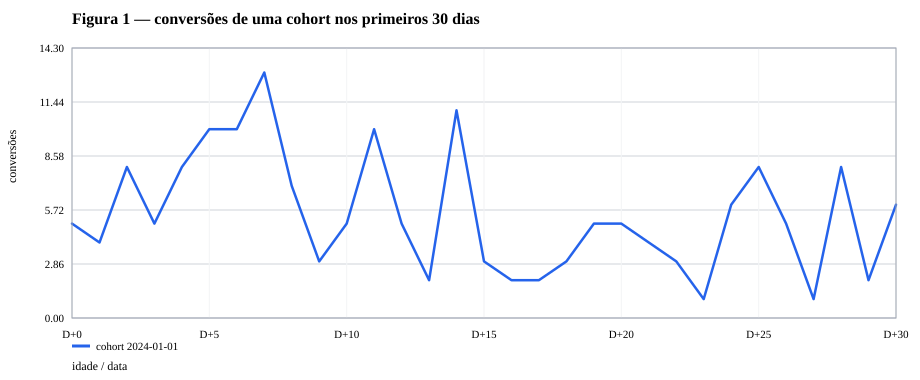

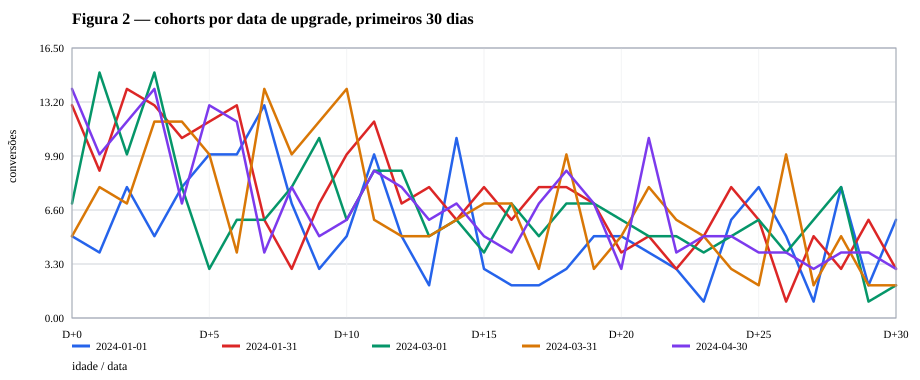

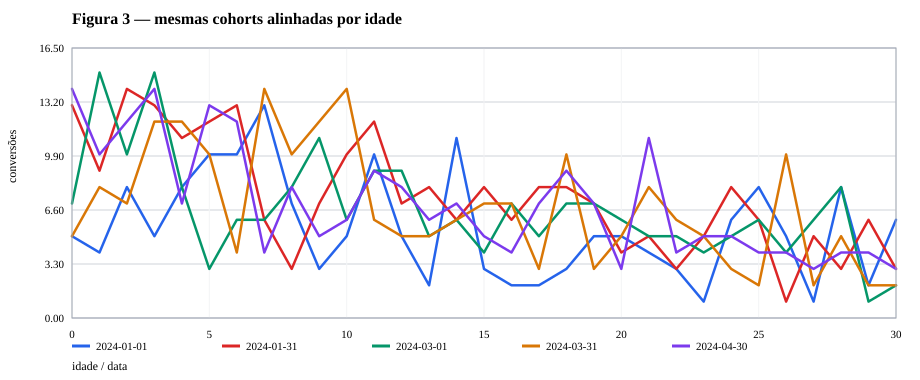

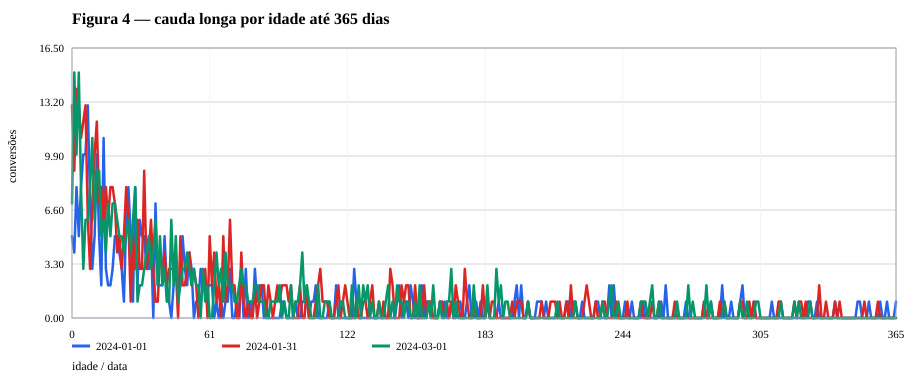

In [14]:
def cohort_counts(registration_date: date, max_age: int) -> List[float]:
    values = {
        row.age: float(row.conversions)
        for row in cells
        if row.registration_date == registration_date and row.age <= max_age
    }
    return [values.get(age, 0.0) for age in range(max_age + 1)]


figure1_registration = start_date
display(
    render_line_chart(
        [("cohort 2024-01-01", cohort_counts(figure1_registration, 30))],
        [f"D+{age}" for age in range(31)],
        "Figura 1 — conversões de uma cohort nos primeiros 30 dias",
        "conversões",
    )
)

figure2_registrations = [
    start_date + timedelta(days=day)
    for day in [0, 30, 60, 90, 120]
]
display(
    render_line_chart(
        [
            (str(registration), cohort_counts(registration, 30))
            for registration in figure2_registrations
        ],
        [f"D+{age}" for age in range(31)],
        "Figura 2 — cohorts por data de upgrade, primeiros 30 dias",
        "conversões",
    )
)

display(
    render_line_chart(
        [
            (str(registration), cohort_counts(registration, 30))
            for registration in figure2_registrations
        ],
        [str(age) for age in range(31)],
        "Figura 3 — mesmas cohorts alinhadas por idade",
        "conversões",
    )
)

figure4_registrations = [
    start_date + timedelta(days=day)
    for day in [0, 30, 60]
]
display(
    render_line_chart(
        [
            (str(registration), cohort_counts(registration, 365))
            for registration in figure4_registrations
        ],
        [str(age) for age in range(366)],
        "Figura 4 — cauda longa por idade até 365 dias",
        "conversões",
    )
)


### Figuras 5–8 — cohorts recentes, futuras e antigas

Agora o eixo passa a ser a data futura. As linhas de cohorts recentes são extrapolações; as futuras dependem de uma hipótese sobre o tamanho de aquisição; as antigas contribuem pouco individualmente, mas podem somar bastante.


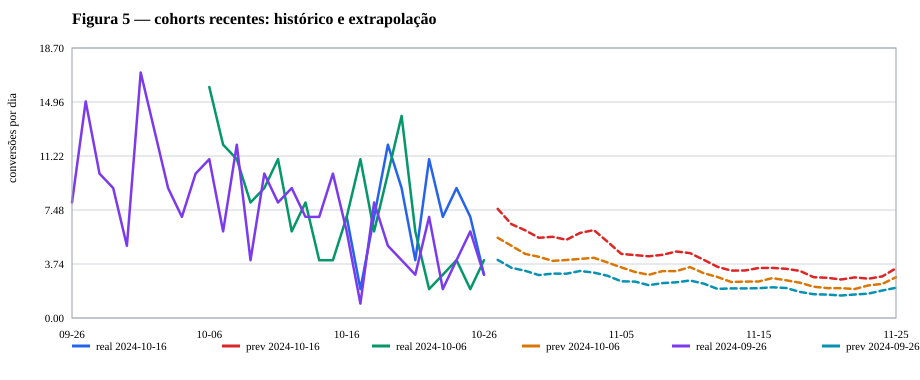

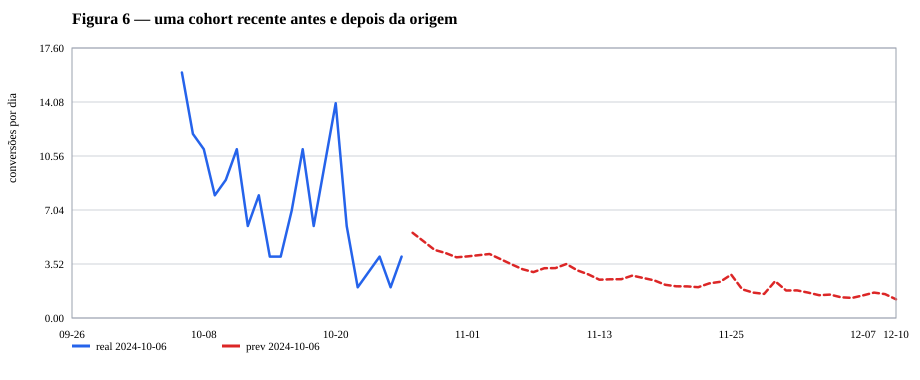

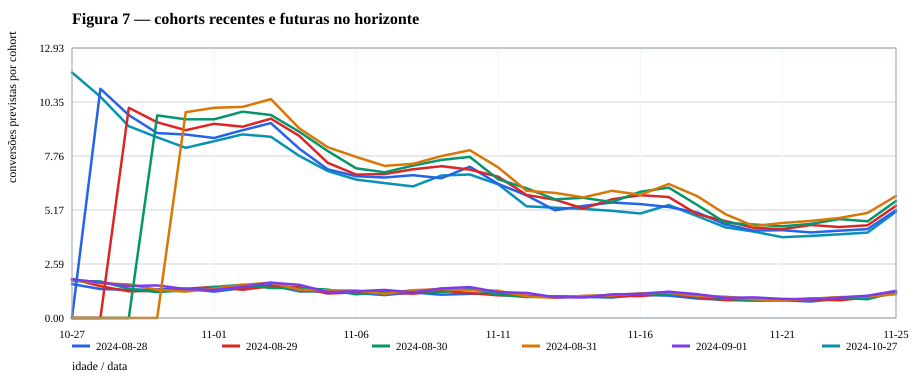

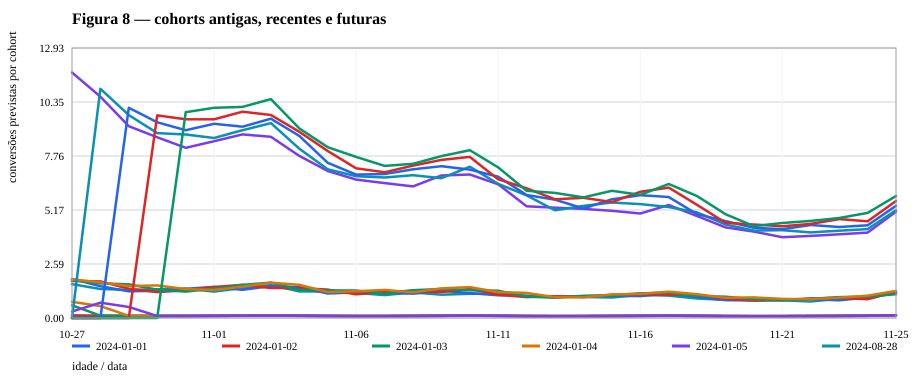

In [15]:
known_sizes = {
    registration: size
    for registration, size in cohort_sizes.items()
    if registration <= forecast_origin
}
recent_model_60 = CohortRateModel.fit(cells, forecast_origin, cutoff_age=60)
recent_predictions_60 = recent_model_60.forecast_cells(
    forecast_origin,
    60,
    known_sizes,
)
predicted_by_registration = defaultdict(dict)
for row in recent_predictions_60:
    predicted_by_registration[row["registration_date"]][row["event_date"]] = row["prediction"]

def actual_by_registration(registration_date: date, horizon: int) -> List[float]:
    return [
        float(row.conversions)
        for row in cells
        if row.registration_date == registration_date
        and row.age <= horizon
    ]

def optional_recent_series(registrations: Sequence[date], horizon: int):
    series = []
    x_labels = [str(forecast_origin + timedelta(days=step))[5:] for step in range(-30, horizon + 1)]
    for registration in registrations:
        actual_map = {
            row.event_date: float(row.conversions)
            for row in cells
            if row.registration_date == registration
        }
        prediction_map = predicted_by_registration[registration]
        values_actual = []
        values_forecast = []
        for step in range(-30, horizon + 1):
            day = forecast_origin + timedelta(days=step)
            values_actual.append(actual_map.get(day) if day <= forecast_origin else None)
            values_forecast.append(prediction_map.get(day) if day > forecast_origin else None)
        series.extend([
            (f"real {registration}", values_actual, False),
            (f"prev {registration}", values_forecast, True),
        ])
    return x_labels, series

recent_registrations = [
    forecast_origin - timedelta(days=days)
    for days in [10, 20, 30]
]
x_labels, recent_series = optional_recent_series(recent_registrations, 30)
display(
    render_optional_line_chart(
        recent_series,
        x_labels,
        "Figura 5 — cohorts recentes: histórico e extrapolação",
        "conversões por dia",
    )
)

one_recent = [forecast_origin - timedelta(days=20)]
x_labels, one_recent_series = optional_recent_series(one_recent, 45)
display(
    render_optional_line_chart(
        one_recent_series,
        x_labels,
        "Figura 6 — uma cohort recente antes e depois da origem",
        "conversões por dia",
    )
)

forecast_days_30 = sorted(predicted_totals)
by_registration = defaultdict(lambda: defaultdict(float))
for row in predicted_cells:
    by_registration[row["registration_date"]][row["event_date"]] += row["prediction"]

selected_recent = [
    registration
    for registration in sorted(by_registration)
    if registration <= forecast_origin
    and (forecast_origin - registration).days < 60
][:5]
selected_future = [
    registration
    for registration in sorted(by_registration)
    if registration > forecast_origin
][:5]

def individual_forecast_series(registrations: Sequence[date], horizon: int):
    labels = [str(forecast_origin + timedelta(days=step))[5:] for step in range(1, horizon + 1)]
    return [
        (
            str(registration),
            [by_registration[registration].get(
                forecast_origin + timedelta(days=step), 0.0
            ) for step in range(1, horizon + 1)],
        )
        for registration in registrations
    ], labels

recent_lines, labels = individual_forecast_series(selected_recent, 30)
future_lines, _ = individual_forecast_series(selected_future, 30)
display(
    render_line_chart(
        recent_lines + future_lines,
        labels,
        "Figura 7 — cohorts recentes e futuras no horizonte",
        "conversões previstas por cohort",
    )
)

selected_old = [
    registration
    for registration in sorted(by_registration)
    if registration <= forecast_origin
    and (forecast_origin - registration).days >= 60
][:5]
old_lines, _ = individual_forecast_series(selected_old, 30)
display(
    render_line_chart(
        old_lines + recent_lines + future_lines,
        labels,
        "Figura 8 — cohorts antigas, recentes e futuras",
        "conversões previstas por cohort",
    )
)


### Figuras 9–12 — agregação, calendário e tendência

A agregação recupera a série temporal que um modelo tradicional tentaria prever diretamente. A diferença é que agora conseguimos explicar cada parcela do total.


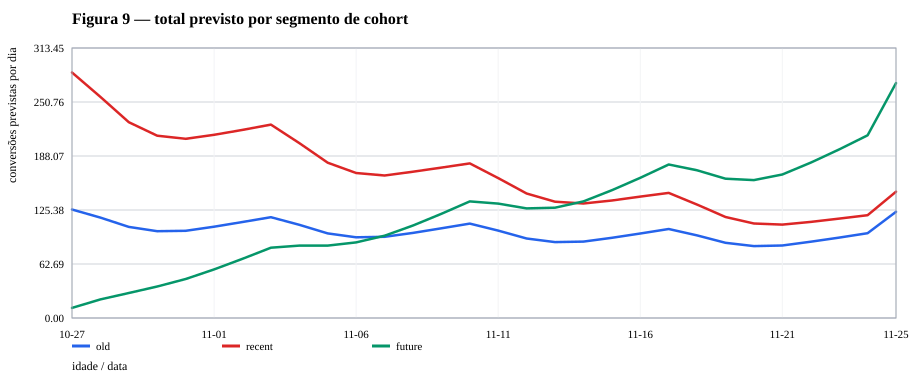

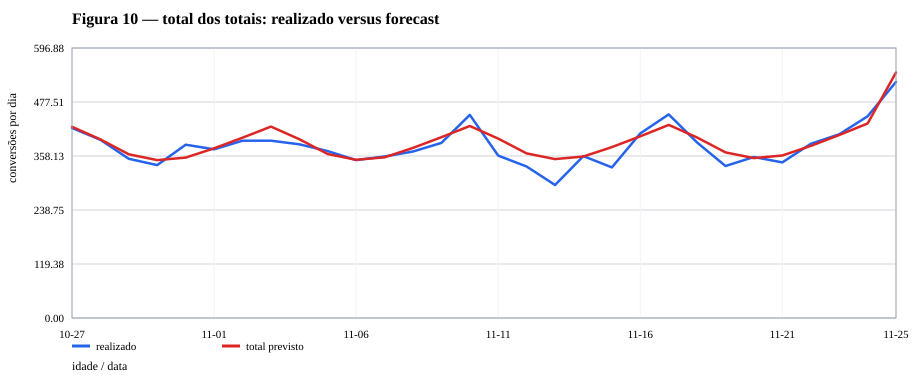

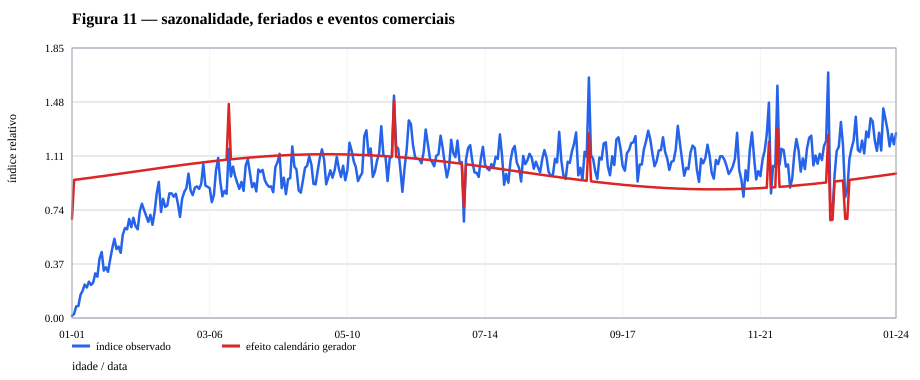

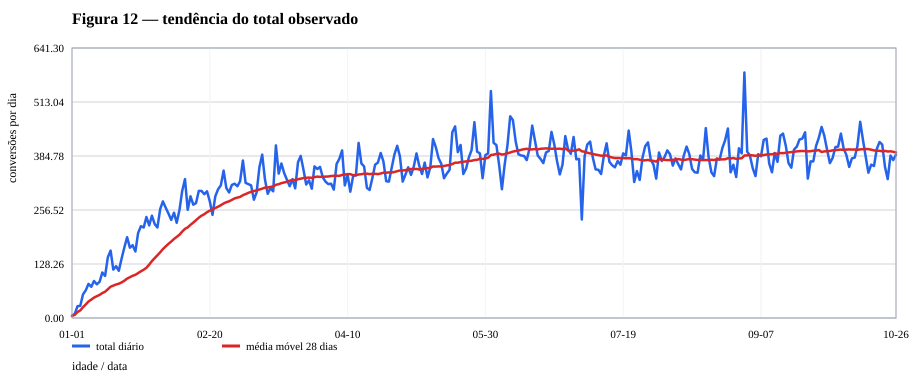

In [16]:
segment_series = []
for segment in ["old", "recent", "future"]:
    values = [
        sum(
            row["prediction"]
            for row in predicted_cells
            if row["event_date"] == day and row["segment"] == segment
        )
        for day in forecast_days_30
    ]
    segment_series.append((segment, values))

display(
    render_line_chart(
        segment_series,
        [str(day)[5:] for day in forecast_days_30],
        "Figura 9 — total previsto por segmento de cohort",
        "conversões previstas por dia",
    )
)

display(
    render_line_chart(
        [
            ("realizado", [actuals[day] for day in forecast_days_30]),
            ("total previsto", [predicted_totals[day] for day in forecast_days_30]),
        ],
        [str(day)[5:] for day in forecast_days_30],
        "Figura 10 — total dos totais: realizado versus forecast",
        "conversões por dia",
    )
)

calendar_days = sorted(actuals)
calendar_index = [actuals[day] / max(mean(actuals.values()), 1.0) for day in calendar_days]
calendar_factor = [calendar_effect(day) for day in calendar_days]
display(
    render_line_chart(
        [
            ("índice observado", calendar_index),
            ("efeito calendário gerador", calendar_factor),
        ],
        [str(day)[5:] for day in calendar_days],
        "Figura 11 — sazonalidade, feriados e eventos comerciais",
        "índice relativo",
    )
)

history_days = [day for day in sorted(actuals) if day <= forecast_origin]
history_values = [actuals[day] for day in history_days]
moving_average = []
for index in range(len(history_values)):
    window = history_values[max(0, index - 27): index + 1]
    moving_average.append(mean(window))
display(
    render_line_chart(
        [
            ("total diário", history_values),
            ("média móvel 28 dias", moving_average),
        ],
        [str(day)[5:] for day in history_days],
        "Figura 12 — tendência do total observado",
        "conversões por dia",
    )
)


### Figuras 13–15 — distribuição, lei de potência e splines

As figuras seguintes explicam por que uma regressão gaussiana simples pode ser inadequada: o alvo é assimétrico, a idade tem relação não linear e uma base spline consegue representar essa curva sem impor uma reta.


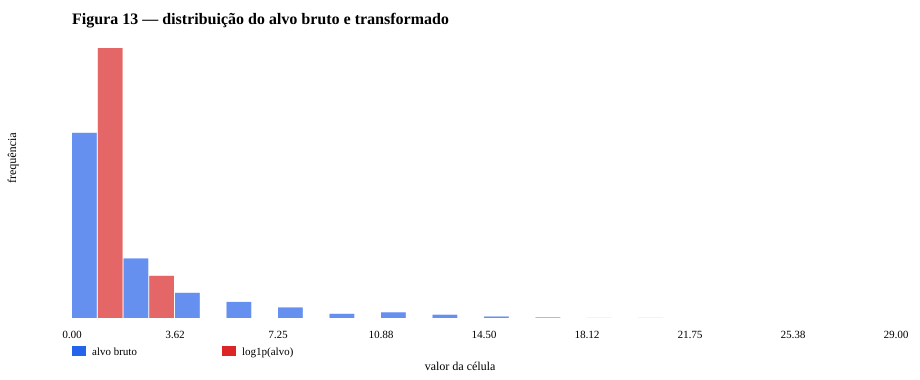

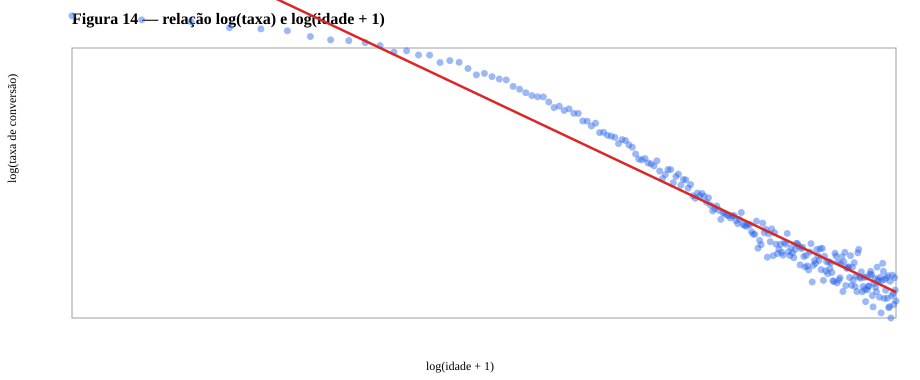

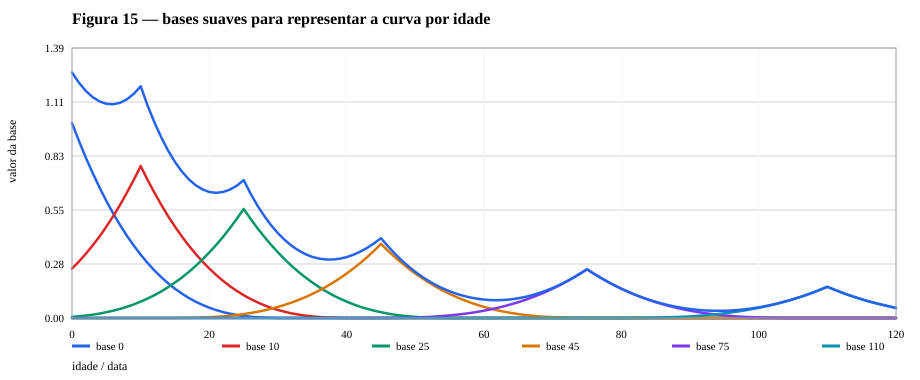

In [17]:
cell_targets = [float(row.conversions) for row in cells if row.event_date <= forecast_origin]
log_targets = [__import__("math").log1p(value) for value in cell_targets]
display(
    render_histogram(
        [
            ("alvo bruto", cell_targets),
            ("log1p(alvo)", log_targets),
        ],
        "Figura 13 — distribuição do alvo bruto e transformado",
        "valor da célula",
    )
)

rate_by_age = {}
for age in range(1, 241):
    rows = [
        row for row in cells
        if row.age == age
        and row.event_date <= forecast_origin
        and row.registration_date <= forecast_origin
    ]
    if rows:
        rate_by_age[age] = sum(row.conversions for row in rows) / sum(
            row.cohort_size for row in rows
        )

log_points = [
    (__import__("math").log(age + 1), __import__("math").log(rate))
    for age, rate in rate_by_age.items()
    if rate > 0
]
x_mean = mean(x for x, _ in log_points)
y_mean = mean(y for _, y in log_points)
slope = sum((x - x_mean) * (y - y_mean) for x, y in log_points) / max(
    sum((x - x_mean) ** 2 for x, _ in log_points), 1.0e-9
)
intercept = y_mean - slope * x_mean
display(
    render_scatter_chart(
        log_points,
        "Figura 14 — relação log(taxa) e log(idade + 1)",
        "log(idade + 1)",
        "log(taxa de conversão)",
        line=(slope, intercept),
    )
)

spline_ages = list(range(0, 121))
centers = [0, 10, 25, 45, 75, 110]
weights = [1.0, 0.78, 0.56, 0.38, 0.25, 0.16]
basis_series = []
for center, weight in zip(centers, weights):
    width = 32.0
    basis = [
        weight * max(0.0, 1.0 - abs(age - center) / width) ** 3
        for age in spline_ages
    ]
    basis_series.append((f"base {center}", basis))
combined = [
    sum(values[index] for _, values in basis_series)
    for index in range(len(spline_ages))
]
basis_series.append(("combinação", combined))
display(
    render_line_chart(
        basis_series,
        [str(age) for age in spline_ages],
        "Figura 15 — bases suaves para representar a curva por idade",
        "valor da base",
    )
)


### Figuras 16–17 — cutoff e validação walk-forward

O cutoff entre cohorts antigas e recentes é um hiperparâmetro. A escolha correta é a que produz o menor erro agregado fora da amostra, não necessariamente 365 dias.

A última figura mostra visualmente por que o treino precisa sempre ficar à esquerda do teste no eixo do tempo.


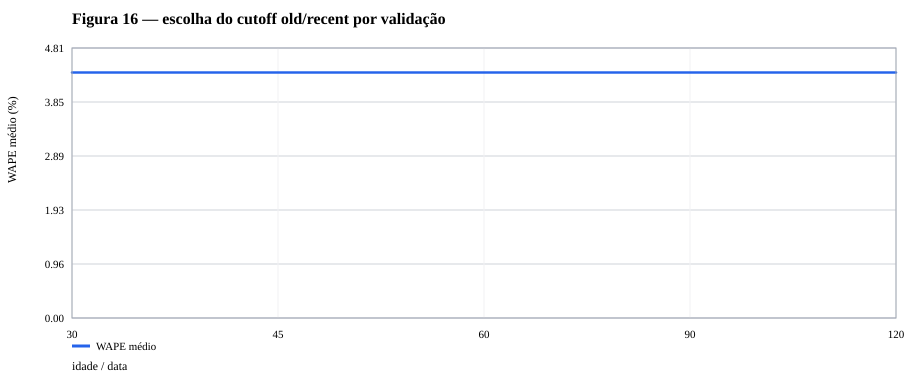

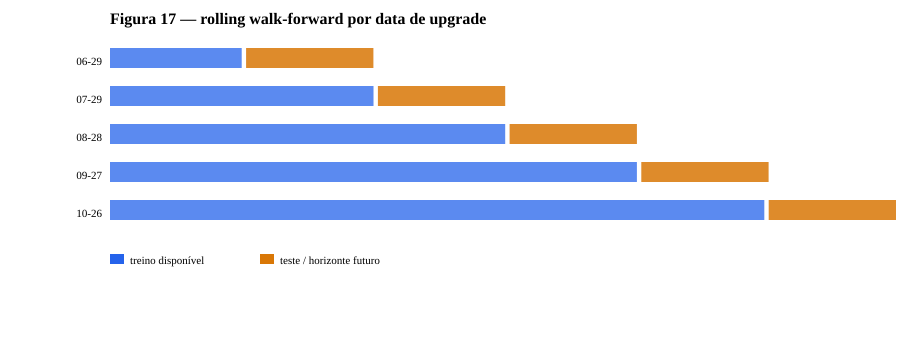

In [18]:
cutoff_grid = [30, 45, 60, 90, 120]
cutoff_results = []
for cutoff in cutoff_grid:
    cutoff_evaluation = walk_forward_evaluation(
        cells,
        cohort_sizes,
        origins,
        horizon=30,
        cutoff_age=cutoff,
    )
    cutoff_results.append(
        mean(row["cohort_wape"] * 100 for row in cutoff_evaluation)
    )

display(
    render_line_chart(
        [("WAPE médio", cutoff_results)],
        [str(cutoff) for cutoff in cutoff_grid],
        "Figura 16 — escolha do cutoff old/recent por validação",
        "WAPE médio (%)",
    )
)

display(
    render_timeline(
        origins,
        horizon=30,
        title="Figura 17 — rolling walk-forward por data de upgrade",
    )
)


### Conclusão da réplica

As 17 figuras agora estão ligadas ao mesmo processo gerador e ao mesmo forecast. Isso deixa três coisas visíveis:

- a curva de idade é o principal sinal de maturação;
- calendário e tendência são efeitos independentes que precisam entrar como features;
- a vantagem do modelo cohort-based não é apenas reduzir erro: é explicar a origem do forecast e permitir escolher o cutoff com validação.
